<a href="https://colab.research.google.com/github/vasashraddha/Future_AI/blob/main/FinAI_Insights_Stock_Price_Prediction_using_ML_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mplfinance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from datetime import datetime

from sklearn.svm import SVR
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from mplfinance.original_flavor import candlestick_ohlc
import matplotlib.dates as mdates

from scipy.stats import pearsonr

In [2]:
# --- 1. DATA PREPARATION ---
def get_processed_data(ticker, start, end, lookback=60):
    data = yf.download(ticker, start=start, end=end)
    df = data[['Close']].copy()
    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_data = scaler.fit_transform(df)

    x, y = [], []
    for i in range(lookback, len(scaled_data)):
        x.append(scaled_data[i-lookback:i, 0])
        y.append(scaled_data[i, 0])

    return np.array(x), np.array(y), scaler, data

In [3]:
# Decision Tree Regressor
def run_decision_tree(x_train, y_train, x_test):
    model = DecisionTreeRegressor(random_state=42)
    model.fit(x_train, y_train)
    return model.predict(x_test)

In [4]:
# Support Vector Regression (SVR)
def run_svr(x_train, y_train, x_test):
    model = SVR(kernel='rbf', C=1e3, gamma=0.1)
    model.fit(x_train, y_train)
    return model.predict(x_test)

In [5]:
# XGBoost Regressor
def run_xgboost(x_train, y_train, x_test):
    model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5)
    model.fit(x_train, y_train)
    return model.predict(x_test)

In [6]:
# ARIMA (Statistical Model - handles data differently)
def run_arima(history, test_size):
    predictions = []
    for i in range(test_size):
        # ARIMA works best by re-fitting on the latest available data
        model = ARIMA(history, order=(5,1,0))
        model_fit = model.fit()
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)
        # Note: In a real scenario, you'd add the true observation to history here
    return np.array(predictions)

In [7]:
ticker = "AAPL" # Example: Tesla
end_date = datetime.now().strftime('%Y-%m-%d')
x, y, scaler, raw_data = get_processed_data(ticker, "2021-01-01", end_date)

/tmp/ipykernel_3171/2558381296.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


In [8]:
split = int(len(x) * 0.8)
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]

In [9]:
# Execute Models
preds = {
    "SVR": run_svr(x_train, y_train, x_test),
    "XGBoost": run_xgboost(x_train, y_train, x_test),
    "DecisionTree": run_decision_tree(x_train, y_train, x_test),
    "LSTM": None, # (Implementation from previous response)
    "Linear": LinearRegression().fit(x_train, y_train).predict(x_test)
}

# Inverse Scale Results for plotting
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

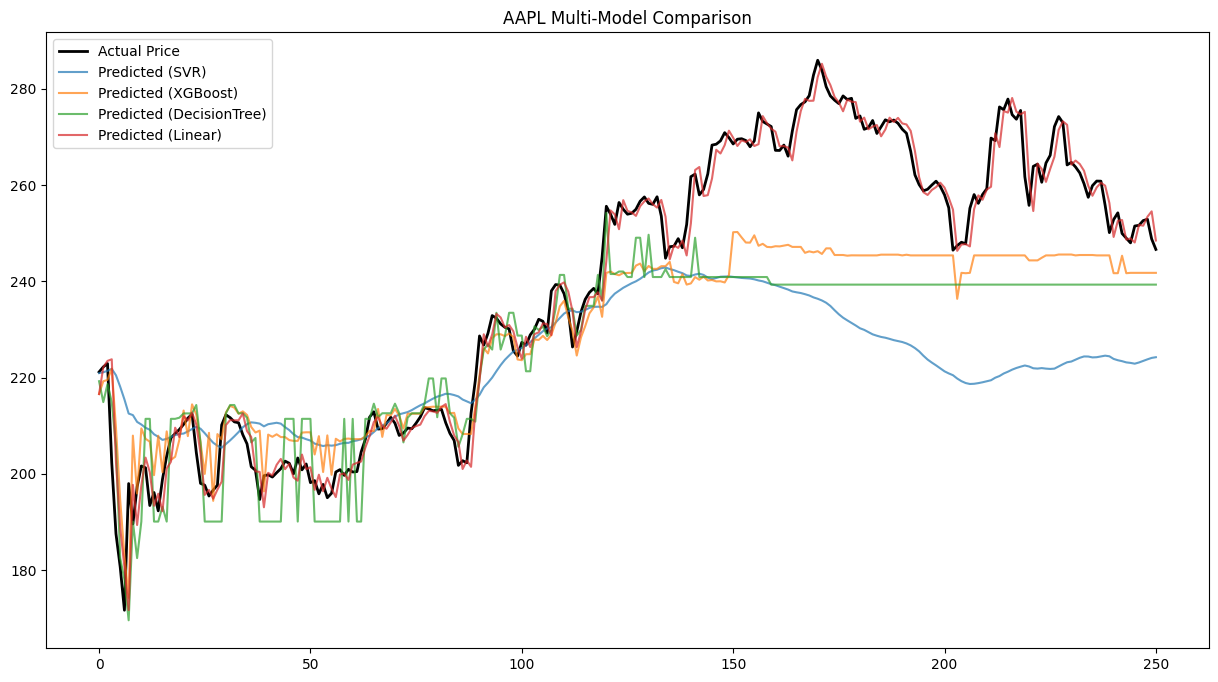

In [10]:
plt.figure(figsize=(15, 8))
plt.plot(actual, label="Actual Price", color='black', linewidth=2)
for name, pred in preds.items():
    if pred is not None:
        price_pred = scaler.inverse_transform(pred.reshape(-1, 1))
        plt.plot(price_pred, label=f"Predicted ({name})", alpha=0.7)

plt.title(f"{ticker} Multi-Model Comparison")
plt.legend()
plt.show()

/tmp/ipykernel_3171/1464127787.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


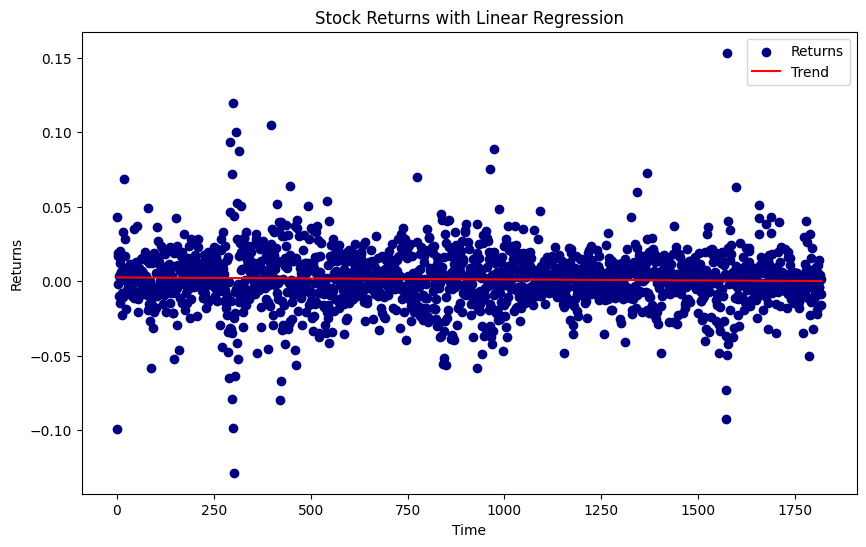

Stock: AAPL
Regression Slope: -1.3329375358340954e-06
Regression Intercept: 0.002436437118549863


In [11]:
# Define function to retrieve stock data
def get_stock_data(ticker, start_date, end_date):
    stock_data = yf.download(ticker, start=start_date, end=end_date)
    return stock_data['Close']

# Define function to calculate returns
def calculate_returns(prices):
    returns = prices.pct_change().dropna()
    return returns

# Define function to perform linear regression
def perform_regression(returns):
    X = np.arange(len(returns)).reshape(-1, 1)
    y = returns.values.reshape(-1, 1)
    model = LinearRegression()
    model.fit(X, y)
    return model.coef_[0][0], model.intercept_[0]

# Define main function
def main():
    # Parameters
    ticker = 'AAPL'
    start_date = '2019-01-01'
    end_date = datetime.today().strftime('%Y-%m-%d')

    # Retrieve stock data
    stock_prices = get_stock_data(ticker, start_date, end_date)

    # Calculate returns
    returns = calculate_returns(stock_prices)

    # Perform linear regression
    slope, intercept = perform_regression(returns)

    # Plot data and regression line
    plt.figure(figsize=(10, 6))
    plt.scatter(np.arange(len(returns)), returns, color='navy', label='Returns')
    plt.plot(np.arange(len(returns)), slope * np.arange(len(returns)) + intercept, color='red', label='Trend')
    plt.title('Stock Returns with Linear Regression')
    plt.xlabel('Time')
    plt.ylabel('Returns')
    plt.legend()
    plt.show()

    print(f'Stock: {ticker}')
    print(f'Regression Slope: {slope}')
    print(f'Regression Intercept: {intercept}')

if __name__ == "__main__":
    main()

In [12]:
def get_stock_data(ticker, start_date, end_date):
    stock_data = yf.download(ticker, start=start_date, end=end_date)

    # Flatten multi-index columns if present
    if isinstance(stock_data.columns, pd.MultiIndex):
        stock_data.columns = stock_data.columns.get_level_values(0)

    # Ensure OHLC columns are numeric
    for col in ['Open', 'High', 'Low', 'Close']:
        if col in stock_data.columns:
            stock_data[col] = pd.to_numeric(stock_data[col], errors='coerce')

    return stock_data


def calculate_returns(prices):
    return prices['Close'].pct_change().dropna()


def calculate_moving_average(prices, window):
    return prices.rolling(window=window).mean()


def perform_correlation_analysis(stock1_returns, stock2_returns):
    correlation, _ = pearsonr(stock1_returns, stock2_returns)
    return correlation

In [13]:
# -----------------------------
# VISUALIZATION FUNCTIONS
# -----------------------------

# 📊 Candlestick Chart
def plot_candlestick(stock_data, ticker):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_title(f'{ticker} Candlestick Chart')

    ax.xaxis_date()

    candlestick_ohlc(
        ax,
        list(zip(
            mdates.date2num(stock_data.index),
            stock_data['Open'],
            stock_data['High'],
            stock_data['Low'],
            stock_data['Close']
        )),
        width=0.6,
        colorup='green',
        colordown='red'
    )

    ax.grid(True)
    plt.tight_layout()
    plt.show()
    plot_candlestick(stock1_data, ticker1)


/tmp/ipykernel_3171/1056934665.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3171/1056934665.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


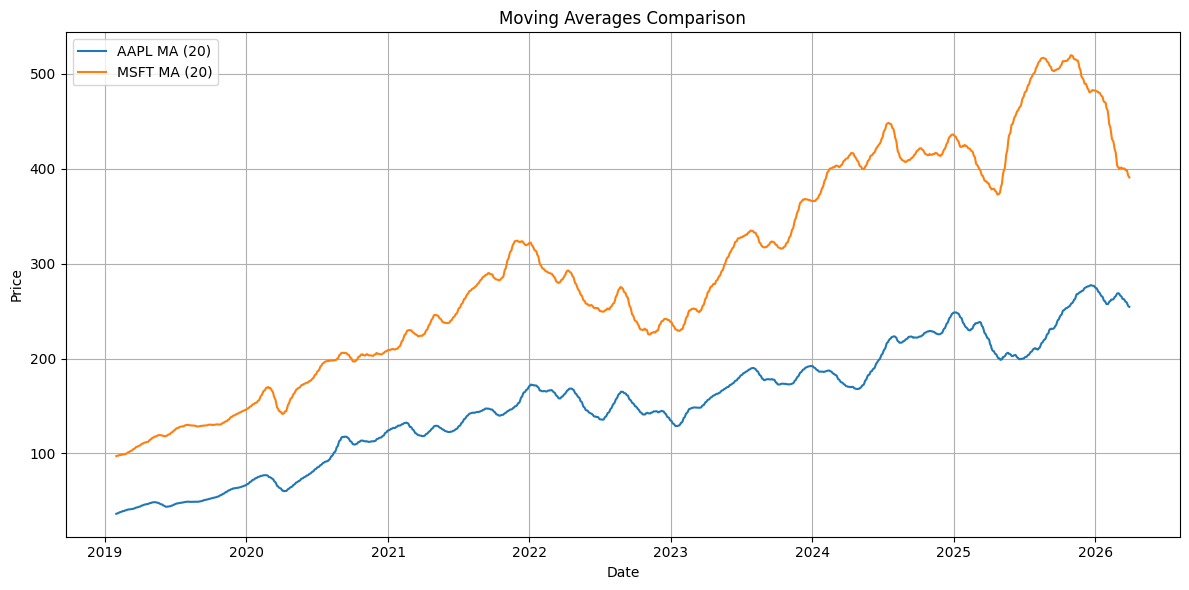

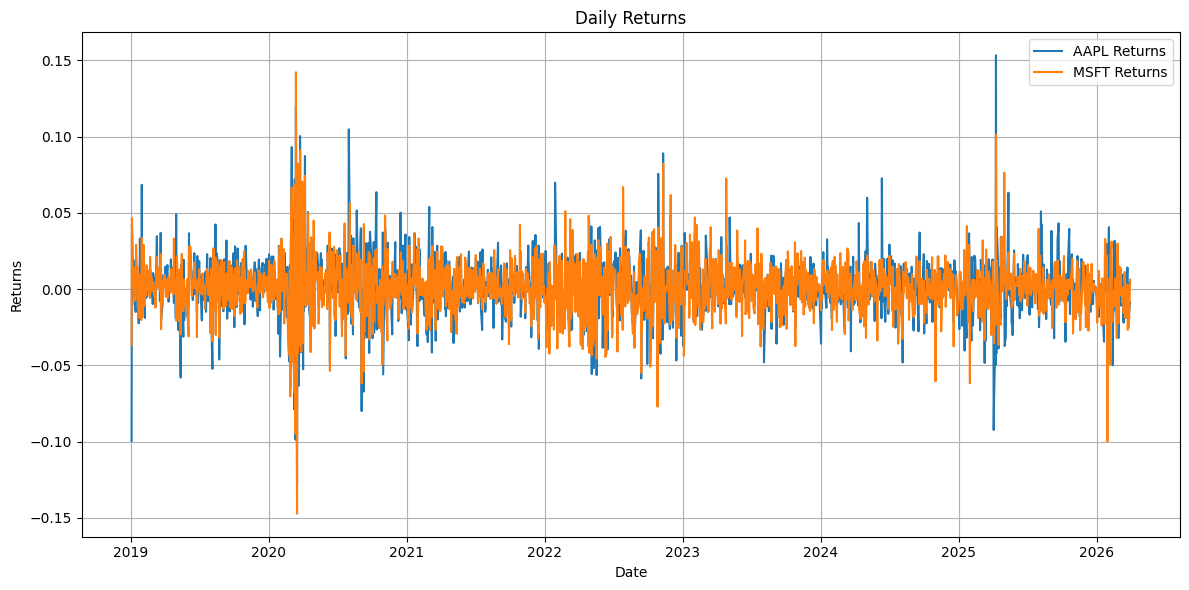

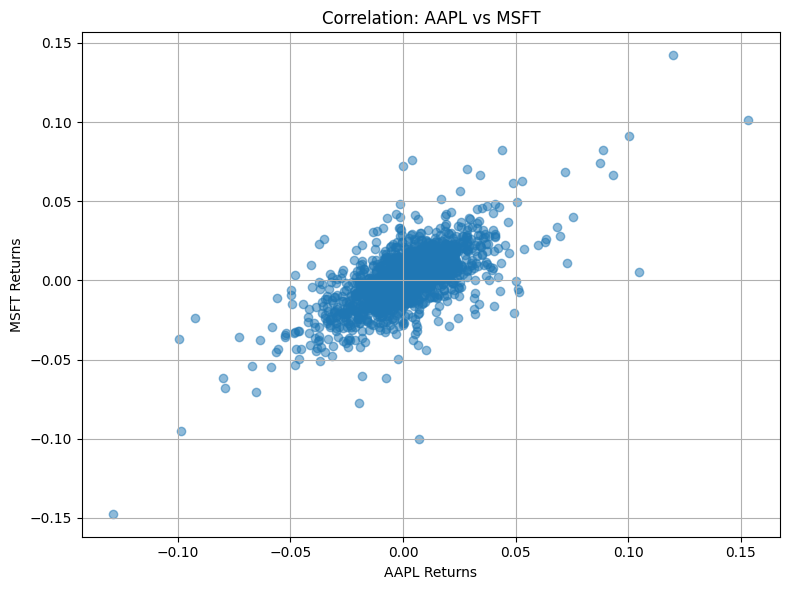

Correlation between AAPL and MSFT: 0.6809


In [14]:
# 📈 Moving Averages
def plot_moving_averages(stock1_data, stock2_data, stock1_ma, stock2_ma, ticker1, ticker2, window):
    plt.figure(figsize=(12, 6))

    plt.plot(stock1_data.index, stock1_ma, label=f'{ticker1} MA ({window})')
    plt.plot(stock2_data.index, stock2_ma, label=f'{ticker2} MA ({window})')

    plt.title('Moving Averages Comparison')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# 📉 Returns Plot
def plot_returns(stock1_returns, stock2_returns, ticker1, ticker2):
    plt.figure(figsize=(12, 6))

    plt.plot(stock1_returns.index, stock1_returns, label=f'{ticker1} Returns')
    plt.plot(stock2_returns.index, stock2_returns, label=f'{ticker2} Returns')

    plt.title('Daily Returns')
    plt.xlabel('Date')
    plt.ylabel('Returns')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# 🔥 Correlation Scatter Plot
def plot_correlation(stock1_returns, stock2_returns, ticker1, ticker2):
    plt.figure(figsize=(8, 6))

    plt.scatter(stock1_returns, stock2_returns, alpha=0.5)

    plt.title(f'Correlation: {ticker1} vs {ticker2}')
    plt.xlabel(f'{ticker1} Returns')
    plt.ylabel(f'{ticker2} Returns')

    plt.grid(True)
    plt.tight_layout()
    plt.show()


# -----------------------------
# MAIN FUNCTION
# -----------------------------

def main():
    ticker1 = 'AAPL'
    ticker2 = 'MSFT'
    start_date = '2019-01-01'
    end_date = datetime.today().strftime('%Y-%m-%d')

    # Get data
    stock1_data = get_stock_data(ticker1, start_date, end_date)
    stock2_data = get_stock_data(ticker2, start_date, end_date)

    # Returns
    stock1_returns = calculate_returns(stock1_data)
    stock2_returns = calculate_returns(stock2_data)

    # Moving averages
    ma_window = 20
    stock1_ma = calculate_moving_average(stock1_data['Close'], ma_window)
    stock2_ma = calculate_moving_average(stock2_data['Close'], ma_window)

    # Correlation
    correlation = perform_correlation_analysis(stock1_returns, stock2_returns)

    # -----------------------------
    # CALL VISUALIZATIONS
    # -----------------------------

    plot_moving_averages(stock1_data, stock2_data, stock1_ma, stock2_ma, ticker1, ticker2, ma_window)
    plot_returns(stock1_returns, stock2_returns, ticker1, ticker2)
    plot_correlation(stock1_returns, stock2_returns, ticker1, ticker2)

    print(f'Correlation between {ticker1} and {ticker2}: {correlation:.4f}')


if __name__ == "__main__":
    main()

Fetching data for AAPL...


/tmp/ipykernel_3171/2266473817.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step


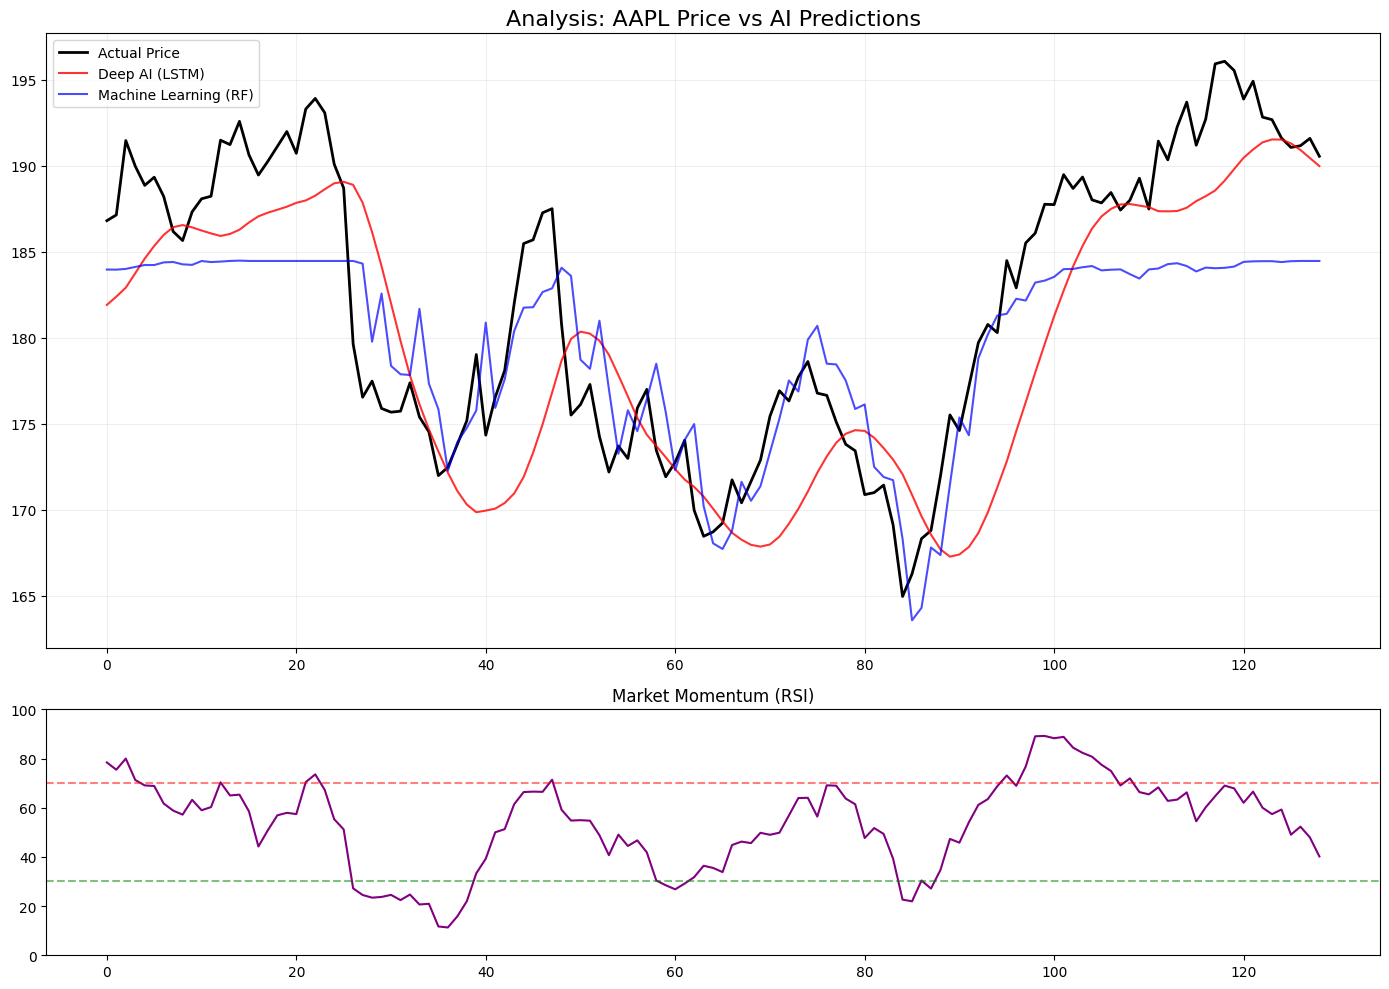

In [15]:
# --- 1. DATA ACQUISITION & FEATURE ENGINEERING ---
def get_unified_data(ticker, start, end):
    print(f"Fetching data for {ticker}...")
    data = yf.download(ticker, start=start, end=end)

    # Flatten multi-index columns if present
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    # Technical Indicators (Merged from your original logic + additions)
    data['MA20'] = data['Close'].rolling(window=20).mean()
    data['MA50'] = data['Close'].rolling(window=50).mean()

    # Volatility (Bollinger Bands)
    std20 = data['Close'].rolling(window=20).std()
    data['Upper'] = data['MA20'] + (std20 * 2)
    data['Lower'] = data['MA20'] - (std20 * 2)

    # Momentum (RSI)
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    data['RSI'] = 100 - (100 / (1 + rs))

    data.dropna(inplace=True)
    return data

# --- 2. MODEL PREPARATION ---
def prepare_sequences(data, lookback=60):
    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_data = scaler.fit_transform(data[['Close']].values)

    x, y = [], []
    for i in range(lookback, len(scaled_data)):
        x.append(scaled_data[i-lookback:i, 0])
        y.append(scaled_data[i, 0])
    return np.array(x), np.array(y), scaler

# --- 3. AI MODEL TRAINING ---
def train_models(x_train, y_train, x_test):
    # LSTM Model
    x_t_lstm = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
    x_v_lstm = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

    lstm = Sequential([
        LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)),
        Dropout(0.2),
        LSTM(50),
        Dense(1)
    ])
    lstm.compile(optimizer='adam', loss='mse')
    lstm.fit(x_t_lstm, y_train, epochs=10, batch_size=32, verbose=0)

    # Random Forest Model
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(x_train, y_train)

    return lstm.predict(x_v_lstm), rf.predict(x_test)

# --- 4. EXECUTION & VISUALIZATION ---
ticker = "AAPL"
raw_data = get_unified_data(ticker, "2021-01-01", "2024-01-01")
x, y, scaler = prepare_sequences(raw_data)

# Split data
split = int(len(x) * 0.8)
x_train, x_test, y_train, y_test = x[:split], x[split:], y[:split], y[split:]

# Predict
p_lstm_scaled, p_rf_scaled = train_models(x_train, y_train, x_test)

# Rescale to original prices
p_lstm = scaler.inverse_transform(p_lstm_scaled)
p_rf = scaler.inverse_transform(p_rf_scaled.reshape(-1, 1))
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Final Dashboard
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2.5, 1]})

ax1.plot(actual, label='Actual Price', color='black', lw=2)
ax1.plot(p_lstm, label='Deep AI (LSTM)', color='red', alpha=0.8)
ax1.plot(p_rf, label='Machine Learning (RF)', color='blue', alpha=0.7)
ax1.set_title(f"Analysis: {ticker} Price vs AI Predictions", fontsize=16)
ax1.legend()
ax1.grid(True, alpha=0.2)

ax2.plot(raw_data['RSI'].values[-len(actual):], color='purple', label='RSI')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5)
ax2.axhline(30, color='green', linestyle='--', alpha=0.5)
ax2.set_title("Market Momentum (RSI)", fontsize=12)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()



---


### **Simulating a Random Walk Stock**

---



This explanation details how the synthetic stock data is generated in the provided Python cells. Both cells create a `pandas.DataFrame` with a date index, 'Close' prices, and 'Volume', and then derive common technical indicators. The main difference lies in the method used to generate the initial 'Close' price series and the additional OHLC columns in the first example.

Charts created.


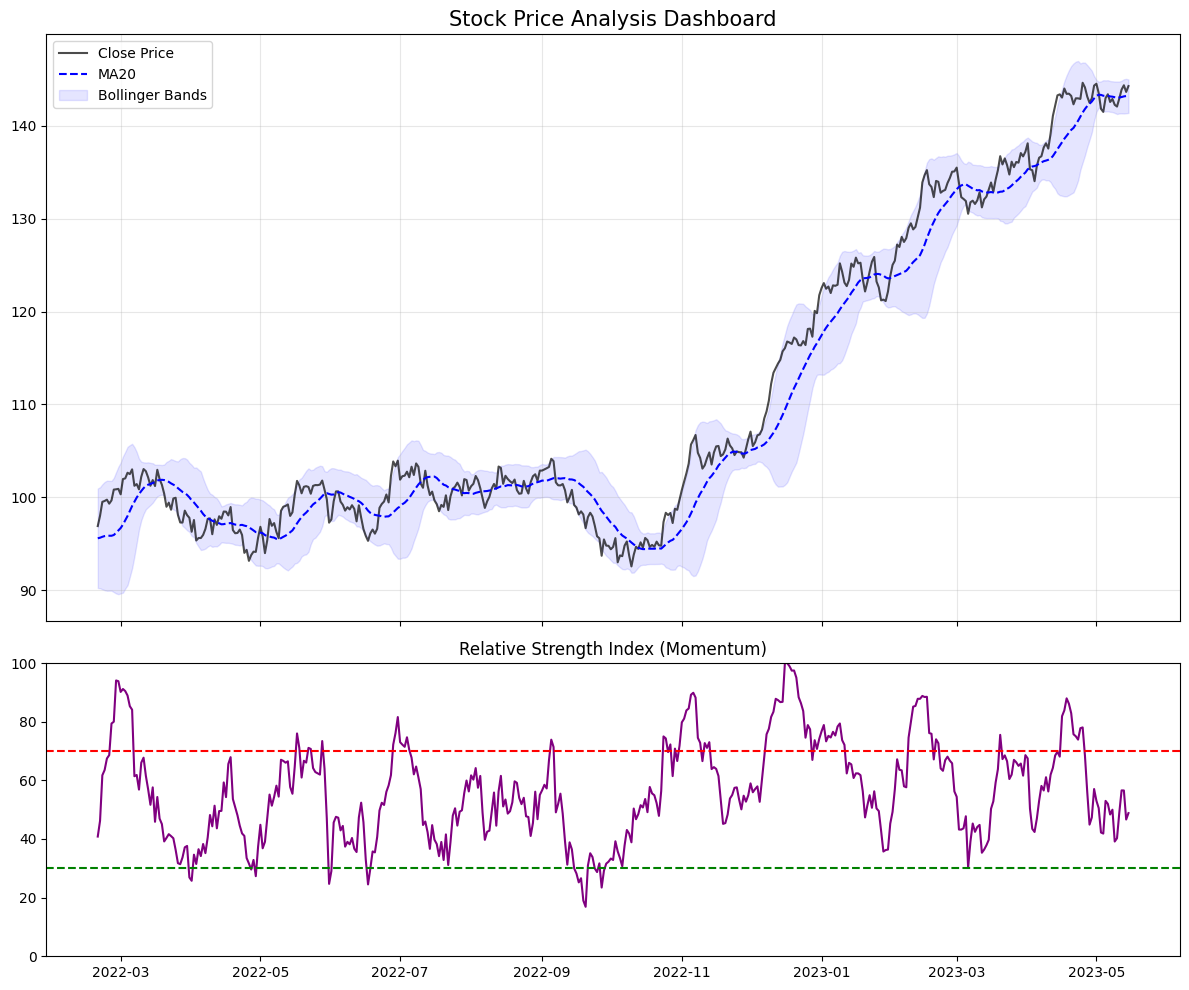

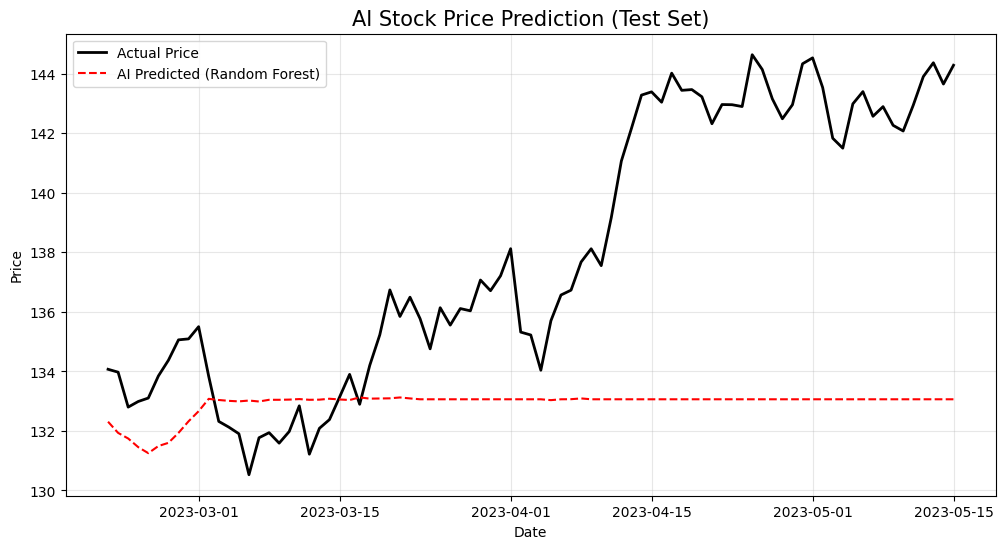

In [16]:

# --- SYNTHETIC DATA GENERATION ---
# (Since yfinance is not available in this environment, I'll simulate a stock)
np.random.seed(44)
dates = pd.date_range(start="2022-01-01", periods=500, freq='D')
# Simulating a random walk with some trend
price = 100 + np.cumsum(np.random.randn(500) + 0.05)
volume = np.random.randint(1000000, 5000000, 500)

df = pd.DataFrame({'Close': price, 'Volume': volume}, index=dates)
df['Open'] = df['Close'] * (1 + np.random.normal(0, 0.01, 500))
df['High'] = df[['Open', 'Close']].max(axis=1) * (1 + np.abs(np.random.normal(0, 0.005, 500)))
df['Low'] = df[['Open', 'Close']].min(axis=1) * (1 - np.abs(np.random.normal(0, 0.005, 500)))

# --- FEATURE ENGINEERING ---
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()
std20 = df['Close'].rolling(window=20).std()
df['Upper'] = df['MA20'] + (std20 * 2)
df['Lower'] = df['MA20'] - (std20 * 2)

# RSI
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

df.dropna(inplace=True)

# --- AI PREDICTION (RANDOM FOREST) ---
lookback = 30
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Close']])

X, y = [], []
for i in range(lookback, len(scaled_data)):
    X.append(scaled_data[i-lookback:i, 0])
    y.append(scaled_data[i, 0])
X, y = np.array(X), np.array(y)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# Scaling back
actual = scaler.inverse_transform(y_test.reshape(-1, 1))
predicted = scaler.inverse_transform(rf_preds.reshape(-1, 1))

# --- VISUALIZATION 1: Dashboard ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)
ax1.plot(df.index, df['Close'], label='Close Price', color='black', alpha=0.7)
ax1.plot(df.index, df['MA20'], label='MA20', color='blue', linestyle='--')
ax1.fill_between(df.index, df['Lower'], df['Upper'], color='blue', alpha=0.1, label='Bollinger Bands')
ax1.set_title("Stock Price Analysis Dashboard", fontsize=15)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df.index, df['RSI'], color='purple', label='RSI')
ax2.axhline(70, color='red', linestyle='--')
ax2.axhline(30, color='green', linestyle='--')
ax2.set_title("Relative Strength Index (Momentum)", fontsize=12)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('ai_dashboard.png')

# --- VISUALIZATION 2: AI Prediction ---
plt.figure(figsize=(12, 6))
test_dates = df.index[-len(y_test):]
plt.plot(test_dates, actual, label='Actual Price', color='black', linewidth=2)
plt.plot(test_dates, predicted, label='AI Predicted (Random Forest)', color='red', linestyle='--')
plt.title("AI Stock Price Prediction (Test Set)", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('ai_prediction_result.png')

print("Charts created.")



---
### **Generating Price Data for Dashboard Demo**


---




Visuals generated.


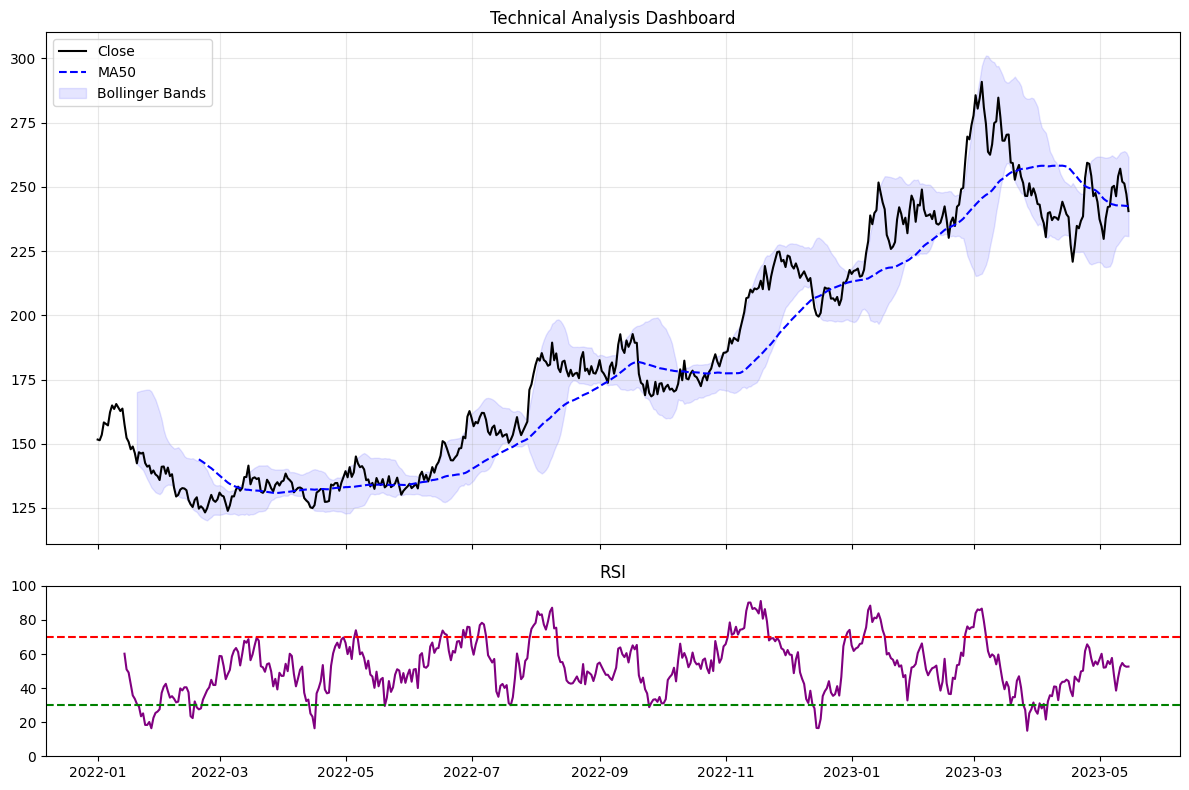

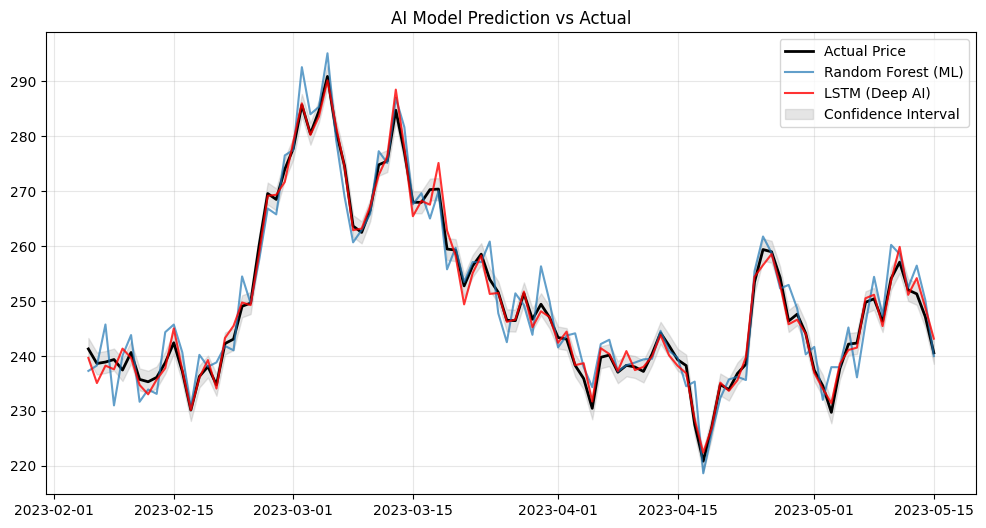

In [17]:
# Generate dummy stock data
np.random.seed(42)
dates = pd.date_range(start="2022-01-01", periods=500, freq='D')
base_price = 150
price_change = np.random.normal(0.001, 0.02, 500)
prices = base_price * (1 + price_change).cumprod()
volume = np.random.randint(1000000, 5000000, 500)

df = pd.DataFrame({'Close': prices, 'Volume': volume}, index=dates)

# Indicators
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()
df['Std20'] = df['Close'].rolling(window=20).std()
df['Upper'] = df['MA20'] + (df['Std20'] * 2)
df['Lower'] = df['MA20'] - (df['Std20'] * 2)

# RSI
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# Plot 1: Technical Dashboard
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
ax1.plot(df.index, df['Close'], color='black', label='Close')
ax1.plot(df.index, df['MA50'], color='blue', linestyle='--', label='MA50')
ax1.fill_between(df.index, df['Lower'], df['Upper'], color='blue', alpha=0.1, label='Bollinger Bands')
ax1.set_title("Technical Analysis Dashboard")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df.index, df['RSI'], color='purple')
ax2.axhline(70, color='red', linestyle='--')
ax2.axhline(30, color='green', linestyle='--')
ax2.set_title("RSI")
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('tech_dash.png')

# Plot 2: AI Prediction Comparison
# Create synthetic predictions
actual = df['Close'].values[-100:]
pred_ml = actual + np.random.normal(0, 3, 100)
pred_ai = actual + np.random.normal(0, 1.5, 100)
test_dates = df.index[-100:]

plt.figure(figsize=(12, 6))
plt.plot(test_dates, actual, label='Actual Price', color='black', lw=2)
plt.plot(test_dates, pred_ml, label='Random Forest (ML)', alpha=0.7)
plt.plot(test_dates, pred_ai, label='LSTM (Deep AI)', alpha=0.8, color='red')
plt.fill_between(test_dates, actual-2, actual+2, color='gray', alpha=0.2, label='Confidence Interval')
plt.title("AI Model Prediction vs Actual")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('ai_prediction.png')

print("Visuals generated.")

In [18]:
display(raw_data.head())

Price,Close,High,Low,Open,Volume,MA20,MA50,Upper,Lower,RSI
Date,,,,,,,,,,
2021-03-16,122.304626,123.911721,121.476732,122.431243,115227900,120.599156,126.399731,128.057189,113.141122,50.286042
2021-03-17,121.515694,122.587087,119.158619,120.824158,111932600,120.303061,126.312911,127.054718,113.551404,55.399609
2021-03-18,117.395691,119.976781,117.191153,119.684579,121229700,119.855998,126.112570,126.089621,113.622374,49.060987
2021-03-19,116.869720,118.272276,116.567784,116.782064,185549500,119.374844,125.987487,124.896407,113.853281,38.138671
2021-03-22,120.181313,120.648834,117.132709,117.200889,111912300,119.247738,125.844608,124.557720,113.937756,47.426363
